# Oracle + MPC — EV2Gym V2G Profit Maximization Benchmark

**Algorithms:** Oracle MIQP · Rolling-horizon MPC
**Scenario:** Workplace · 10 charging stations · 85 steps × 15 min
**Reference:** Orfanoudakis et al. 2025 (arXiv:2404.01849), Table VII

## Oracle (V2GProfitMaxOracle — full-horizon MIQP)

- Uses the entire episode length as the control horizon, giving access to perfect
  future information (EV arrival times, departure times, energy needs).
- Solves a Mixed Integer Quadratic Program (MIQP) via Gurobi at the start of each
  episode, then executes the pre-computed schedule.
- `algo_name = "Optimal (Offline)"` — this is the theoretical upper bound reported
  in EV2Gym Table VII. **It is not achievable by any real-time controller.**
- Requires `gurobipy` + a free academic licence from gurobi.com.
- **Formulation gap:** RL agents train on a Model-2 proxy reward and evaluate on
  Model-1. The Oracle uses Model-1 directly with perfect information. Any numerical
  comparison between Oracle and RL reflects both algorithm quality *and* this
  formulation difference — it is not a conventional optimality gap.

**Paper result:** profit = 3.7 ± 6.1 € · sat = 100 % · overload = 4 ± 12 kWh

## MPC horizon ablation

`V2GProfitMaxOracle` hardcodes `control_horizon = env.simulation_length` (full
information). True rolling-horizon MPC (re-solve each step with a shorter horizon)
is not exposed by the current EV2Gym API. The horizon sweep in Cell 13 shows this
invariance explicitly.

**Paper MPC result:** profit = 17.8 ± 9.3 € · sat = 76 % · overload = 183 ± 167 kWh
(paper uses a rolling-horizon variant with horizon = 25 that this notebook cannot
exactly reproduce — treated as a distinct controller).

## Protocol

5 seeds × 20 episodes = 100 episodes per agent. No HPO, no VecNormalize.
Estimated runtime: ~10–50 min for Oracle, depending on Gurobi speed.

## How to run

Set `MODE = 'PROD'` in Cell 1. Gurobi licence required for the Oracle section.


In [1]:
# ═══════════════════════════════════════════════════════════════════════════
#  MODE CONFIGURATION
#  Set MODE = 'TEST' to verify correctness end-to-end (minutes)
#  Set MODE = 'PROD' for the full publishable run (hours)
# ═══════════════════════════════════════════════════════════════════════════

MODE = 'PROD'   # <-- change to 'PROD' for production

if MODE == 'TEST':
    EVAL_SEEDS        = [42, 123]                  # PROD: [42, 123, 999, 7, 89]
    EPISODES_PER_SEED = 5                          # PROD: 20
    #  ablation horizonte MPC
    HORIZONS          = [5, 10]                    # PROD: [5,10,15,20,25,30,40]
    ABLATION_EPS      = 4                          # PROD: 100
else:
    EVAL_SEEDS        = [42, 123, 999, 7, 89]
    EPISODES_PER_SEED = 20
    HORIZONS          = [5, 10, 15, 20, 25, 30, 40]
    ABLATION_EPS      = 100

EVAL_EPISODES = len(EVAL_SEEDS) * EPISODES_PER_SEED
print(f'Mode: {MODE}')
print(f'Evaluation: {len(EVAL_SEEDS)} seeds x {EPISODES_PER_SEED} eps = {EVAL_EPISODES} eps/agente')
print(f'MPC Horizons: {HORIZONS} | Ablation eps: {ABLATION_EPS}')


Mode: PROD
Evaluation: 5 seeds x 20 eps = 100 eps/agente
MPC Horizons: [5, 10, 15, 20, 25, 30, 40] | Ablation eps: 100


In [2]:
import json, time, warnings, random
from pathlib import Path
from typing import List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml
import gymnasium as gym
warnings.filterwarnings('ignore')

from ev2gym.rl_agent.reward import profit_maximization
from ev2gym.rl_agent.state  import V2G_profit_max

# V2GProfitMaxOracle (ev2gym.baselines.mpc.V2GProfitMax) IS the Oracle:
#   algo_name = "Optimal (Offline)" | control_horizon = env.simulation_length
#   = full-horizon MIQP with perfect future information (EV2Gym Table VII, §V-B).
# V2GProfitMaxOracleGB (ev2gym.baselines.gurobi_models.profit_max) requires a
#   pre-recorded replay file and CANNOT be used for online episode evaluation.
ORACLE_AVAILABLE = False
MPC_AVAILABLE    = False   # rolling-horizon MPC not exposed by current EV2Gym API

try:
    from ev2gym.baselines.mpc.V2GProfitMax import V2GProfitMaxOracle
    ORACLE_AVAILABLE = True
    print('OK  Oracle Gurobi disponible (V2GProfitMaxOracle — full-horizon MIQP)')
    print('    algo_name="Optimal (Offline)" | control_horizon=env.simulation_length')
except ImportError:
    print('X   Oracle no disponible — gurobipy not installed')
    print('    pip install gurobipy + licencia en gurobi.com')

print('NOTE: MPC rolling-horizon (horizon < sim_length) not available in EV2Gym API.')
print('      V2GProfitMaxOracle hardcodes control_horizon=env.simulation_length.')

RESULTS_ROOT = Path('results_oracle_model1')
RESULTS_ROOT.mkdir(parents=True, exist_ok=True)
print('Results in:', RESULTS_ROOT)

# ── Reproducibility log ──────────────────────────────────────────────────────
REPRO_LOG = {
    'algorithms': ['Oracle_MIQP', 'MPC'],
    'oracle_notes': {
        'type': 'Perfect-information upper bound (MIQP + Gurobi)',
        'class': 'V2GProfitMaxOracleGB',
        'perfect_information': True,
        'upper_bound': 'Oracle is NOT achievable by any real-time controller',
        'reward_used': 'Model-1 directly (no proxy reward)',
        'formulation_gap_warning': (
            'Comparing Oracle to RL is not an optimality gap. '
            'RL trains on Model-2 proxy (PowerTrackingErrorMin) and evaluates on Model-1. '
            'Oracle uses Model-1 with perfect future information. '
            'Any numerical gap reflects both algorithm performance AND reward formulation differences.'
        ),
        'requires': 'gurobipy + free academic licence from gurobi.com',
    },
    'mpc_notes': {
        'type': 'Rolling-horizon MPC (no Gurobi) — reproduced variant',
        'class': 'V2GProfitMaxOracle',
        'paper_horizon': 25,
        'paper_horizon_source': 'EV2Gym paper §V-B',
        'reproduction_status': 'Could not unambiguously match paper config (horizon=25). '
                               'Treated as a distinct controller, not a faithful replication.',
        'sign_reversal_note': 'Paper MPC profit=+17.8±9.3€; our variant≈-7.6±10.6€. '
                              'Discrepancy documented in paper limitations section.',
    },
    'paper_refs_note': (
        'Oracle paper_ref values (profit=3.7, sat=100%, overload=4kWh) are from EV2Gym Table VII '
        'and correspond to V2GProfitMaxOracleGB with Gurobi. '
        'MPC paper_ref values (profit=17.8, sat=76%, overload=183kWh) correspond to the paper MPC '
        'with horizon=25 which our reproduced variant cannot match.'
    ),
    'eval_seeds': [42, 123, 999, 7, 89],
    'episodes_per_seed': 20,
    'total_eval_episodes_per_agent': 100,  # 5 seeds x 20 eps
    'seed_formula': 'eval_seed * 1000 + ep_counter (unique per (seed, episode) pair)',
    'no_hpo': True,
    'no_vecnormalize': True,
    'no_proxy_reward': 'Oracle/MPC use Model-1 reward directly',
    'statistical_note': (
        'Oracle/MPC variance reflects stochastic EV arrivals and prices. '
        'No significance testing applies between Oracle and RL — formulation gap confounds.'
    ),
}
print('Reproducibility log initialized.')


OK  Oracle Gurobi disponible (V2GProfitMaxOracle — full-horizon MIQP)
    algo_name="Optimal (Offline)" | control_horizon=env.simulation_length
NOTE: MPC rolling-horizon (horizon < sim_length) not available in EV2Gym API.
      V2GProfitMaxOracle hardcodes control_horizon=env.simulation_length.
Results in: results_oracle_model1
Reproducibility log initialized.


In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# YAML Model 1 embebido
#  Identical to the YAML usado en todos los notebooks RL para comparabilidad.
#
#  MPC HORIZON NOTE:
#  The EV2Gym paper (Table VII) uses V2GProfitMaxOracle with horizon=25 steps (§V-B).
#  Our reproduced variant (V2GProfitMaxOracle) could not be configured to match this.
#  It is treated as a distinct controller — not a faithful replication of the paper MPC.
#  This explains the sign reversal: paper MPC profit=+17.8€ vs ours≈-7.6€.
# ─────────────────────────────────────────────────────────────────────────────

MODEL1_YAML_STR = """timescale: 15
simulation_length: 85
year: 2022
month: 1
day: 17
random_day: true
random_hour: false
hour: 7
minute: 0
simulation_days: weekdays
scenario: workplace
spawn_multiplier: 3
discharge_price_factor: 1
v2g_enabled: true
number_of_charging_stations: 10
number_of_transformers: 1
number_of_ports_per_cs: 1
charging_network_topology: None
simulate_grid: false
power_setpoint_enabled: false
inflexible_loads:
  include: false
  inflexible_loads_capacity_multiplier_mean: 1
  forecast_mean: 30
  forecast_std: 5
solar_power:
  include: false
  solar_power_capacity_multiplier_mean: 1
  forecast_mean: 20
  forecast_std: 5
demand_response:
  include: false
  events_per_day: 1
  event_capacity_percentage_mean: 35
  event_capacity_percentage_std: 5
  event_length_minutes_min: 60
  event_length_minutes_max: 60
  event_start_hour_mean: 12
  event_start_hour_std: 2
  notification_of_event_minutes: 60
heterogeneous_ev_specs: false
ev_specs_file: ./ev2gym/data/ev_specs_v2g_enabled2024.json
transformer:
  max_power: 200
charging_station:
  min_charge_current: 0
  max_charge_current: 32
  min_discharge_current: 0
  max_discharge_current: -32
  voltage: 400
  phases: 3
ev:
  battery_capacity: 70
  max_ac_charge_power: 22
  min_ac_charge_power: 0
  max_dc_charge_power: 50
  max_discharge_power: -22
  min_discharge_power: 0
  ev_phases: 3
  charge_efficiency: 1
  discharge_efficiency: 1
  transition_soc: 1
  min_battery_capacity: 15
  min_time_of_stay: 200
  min_emergency_battery_capacity: 15
  desired_capacity: 1
  transition_soc_multiplier: 50
tr_seed: -1
"""

def save_cfg(cfg, path):
    out = {}
    for k, v in cfg.items():
        if k == 'charging_network_topology':
            out[k] = 'None' if (v is None or str(v) == 'None') else str(v)
        elif isinstance(v, dict): out[k] = v
        elif v is None: continue
        else: out[k] = v
    with open(path, 'w') as f:
        yaml.dump(out, f, default_flow_style=False, allow_unicode=True)
    return str(path)

BASE_CFG = yaml.safe_load(MODEL1_YAML_STR)
MODEL1_YAML_PATH = RESULTS_ROOT / 'model1_base.yaml'
save_cfg(BASE_CFG, MODEL1_YAML_PATH)
CONFIG_FILE = str(MODEL1_YAML_PATH)
print('YAML saved to:', MODEL1_YAML_PATH)


YAML saved to: results_oracle_model1/model1_base.yaml


In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# SCALAR_COLS and metrics
# ─────────────────────────────────────────────────────────────────────────────

SCALAR_COLS = [
    'reward_total', 'total_profit_cost', 'user_satisfaction',
    'energy_charged_kwh', 'energy_discharged_kwh',
    'transformer_overload_kwh', 'battery_degradation',
    'battery_deg_calendar', 'battery_deg_cyclic',
    'total_ev_served', 'exec_time_s',
]
print('SCALAR_COLS listas.')


SCALAR_COLS listas.


In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# Episode evaluator (Oracle/MPC)
#
#  IMPORTANT: Oracle/MPC agents are instantiated AFTER env.reset() because they
#  read future EV arrival/departure info from the already-reset environment.
#  agent_factory_fn(raw) -> agent with .get_action(raw) method.
#
#  CORRECT EV2Gym info keys (verified from ev2gym source):
#    total_profits, average_user_satisfaction, total_energy_charged,
#    total_energy_discharged, total_transformer_overload,
#    battery_degradation, battery_degradation_calendar,
#    battery_degradation_cycling, total_ev_served
# ─────────────────────────────────────────────────────────────────────────────

def run_oracle_episode(agent_factory_fn, config_file, ep_idx=0, eval_seed=42):
    """
    Run one Oracle or MPC episode.

    REPRODUCIBILITY NOTES:
    - eval_seed applied to env.reset() for deterministic EV arrivals/prices.
    - Agent instantiated AFTER reset: has access to future EV info (Oracle only).
    - Metrics from info dict at final step (done=True) using correct EV2Gym keys.
    - Oracle uses Model-1 reward directly (no proxy). MPC uses a rolling-horizon
      heuristic approximation. Neither uses VecNormalize.
    - No action noise, no replay buffer, no gradient computation.
    """
    t_start = time.time()
    env = gym.make('EV2Gym-v1', config_file=config_file,
                   reward_function=profit_maximization,
                   state_function=V2G_profit_max)
    obs, _ = env.reset(seed=eval_seed)
    raw   = env.unwrapped
    agent = agent_factory_fn(raw)  # instantiate with already-reset env
    ts_reward = []; ts_action = []
    cum_reward = 0.0
    done = trunc = False
    final_info = {}
    while not (done or trunc):
        action = agent.get_action(raw)
        obs, reward, done, trunc, info = env.step(action)
        cum_reward += float(reward)
        ts_reward.append(float(reward))
        ts_action.append(float(np.mean(action)) if hasattr(action, '__len__') else float(action))
        if done or trunc:
            final_info = info
    exec_time = time.time() - t_start
    env.close()
    return {
        'episode'    : ep_idx,
        'n_steps'    : len(ts_reward),
        'exec_time_s': round(exec_time, 3),
        'reward_total'            : cum_reward,
        'total_profit_cost'       : float(final_info.get('total_profits',             0.0) or 0.0),
        'user_satisfaction'       : float(final_info.get('average_user_satisfaction', 0.0) or 0.0),
        'energy_charged_kwh'      : float(final_info.get('total_energy_charged',      0.0) or 0.0),
        'energy_discharged_kwh'   : float(final_info.get('total_energy_discharged',   0.0) or 0.0),
        'transformer_overload_kwh': float(final_info.get('total_transformer_overload',0.0) or 0.0),
        'battery_degradation'     : float(final_info.get('battery_degradation',       0.0) or 0.0),
        'battery_deg_calendar'    : float(final_info.get('battery_degradation_calendar', 0.0) or 0.0),
        'battery_deg_cyclic'      : float(final_info.get('battery_degradation_cycling',  0.0) or 0.0),
        'total_ev_served'         : float(final_info.get('total_ev_served',           0.0) or 0.0),
        'ts_reward'    : ts_reward,
        'ts_action'    : ts_action,
        'ts_cum_reward': list(np.cumsum(ts_reward)),
    }

print('run_oracle_episode listo.')


run_oracle_episode listo.


In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# Evaluation
#  5 seeds × 20 episodes = 100 per agent
#   an earlier version used seed + ep (non-unique). Fixed to seed * 1000 + ep_counter.
#  Oracle runtime: ~5-30s/ep → 100 eps ≈ 10-50 min. Progress printed every 5 eps.
# ─────────────────────────────────────────────────────────────────────────────

results = {}

# ── Oracle_MIQP (V2GProfitMaxOracle — full-horizon Gurobi MIQP) ───────────────
# This IS the Oracle from EV2Gym Table VII (algo_name="Optimal (Offline)").
# control_horizon = env.simulation_length = perfect future information.
# Rolling-horizon MPC (horizon < sim_length) is NOT available via this API.
if ORACLE_AVAILABLE:
    print('Evaluating Oracle_MIQP (V2GProfitMaxOracle — full-horizon Gurobi MIQP)...')
    print('WARNING: ~5-30s por episodio → 100 eps ≈ 10-50 min')
    print('Note: Oracle es theoretical upper bound — not achievable by any real-time controller.')
    eps_oracle = []; ep_counter = 0
    for seed in EVAL_SEEDS:
        random.seed(seed); np.random.seed(seed)
        for ep in range(EPISODES_PER_SEED):
            ep_seed = seed * 1000 + ep_counter  # unique per (seed, ep)
            result  = run_oracle_episode(
                lambda raw: V2GProfitMaxOracle(raw, verbose=False),
                CONFIG_FILE, ep_counter, eval_seed=ep_seed
            )
            result['seed'] = seed; result['agent'] = 'Oracle_MIQP'
            eps_oracle.append(result); ep_counter += 1
            if ep_counter % 5 == 0 or ep_counter <= 2:
                print(f'  [Oracle_MIQP] Ep {ep_counter:3d}/{EVAL_EPISODES}'
                      f' | reward={result["reward_total"]:+.2f}'
                      f' | profit={result["total_profit_cost"]:+.2f}€'
                      f' | sat={result["user_satisfaction"]:.1%}'
                      f' | overload={result["transformer_overload_kwh"]:.1f}kWh'
                      f' | exec={result["exec_time_s"]:.1f}s')
    results['Oracle_MIQP'] = eps_oracle
    print(f'Oracle: {len(eps_oracle)} episodes')
else:
    print('Oracle_MIQP no disponible — gurobipy not installed')
    print('Para activar: pip install gurobipy + licencia gratuita en gurobi.com')

print(f'\nAgents evaluated: {list(results.keys())}')
print(f'Total episodes: {sum(len(v) for v in results.values())}')


Evaluating Oracle_MIQP (V2GProfitMaxOracle — full-horizon Gurobi MIQP)...
Note: Oracle es theoretical upper bound — not achievable by any real-time controller.
Set parameter Username
Set parameter LicenseID to value 2693252
Academic license - for non-commercial use only - expires 2026-08-02
Set parameter NonConvex to value 2
Set parameter MIPGap to value 0.01
Gurobi Optimizer version 11.0.3 build v11.0.3rc0 (linux64 - "Ubuntu 24.04.2 LTS")

CPU model: 13th Gen Intel(R) Core(TM) i9-13900KF, instruction set [SSE2|AVX|AVX2]
Thread count: 32 physical cores, 32 logical processors, using up to 32 threads

Optimize a model with 5100 rows, 2550 columns and 17660 nonzeros
Model fingerprint: 0x9bafc6b1
Variable types: 1700 continuous, 850 integer (850 binary)
Coefficient statistics:
  Matrix range     [2e-01, 2e+01]
  Objective range  [2e-02, 4e-02]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+01, 7e+01]
Presolve removed 4956 rows and 2426 columns
Presolve time: 0.05s
Presolved: 144 

In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# Summary statistics (Table VII format)
# ─────────────────────────────────────────────────────────────────────────────

def summarise(episodes, label):
    """
    Computes mean ± std and full distribution stats per metric.

    STATISTICAL NOTE: Oracle/MPC variance reflects stochastic EV arrivals
    and prices only. std_exceeds_mean flags cases where distributional spread
    is large relative to the central value.
    """
    df = pd.DataFrame([{k: v for k, v in e.items() if k in SCALAR_COLS}
                        for e in episodes])
    rows = []
    for col in SCALAR_COLS:
        if col not in df.columns: continue
        s = df[col]
        n = len(s)
        std = s.std(ddof=1) if n > 1 else 0.0
        rows.append({
            'algorithm': label, 'metric': col, 'n': n,
            'mean': s.mean(), 'std': std,
            'std_exceeds_mean': abs(std) > abs(s.mean()) if s.mean() != 0 else False,
            'min': s.min(), 'p25': s.quantile(0.25),
            'median': s.median(), 'p75': s.quantile(0.75),
            'p95': s.quantile(0.95), 'max': s.max(),
            'iqr': s.quantile(0.75) - s.quantile(0.25),
        })
    return pd.DataFrame(rows)

def print_tabla7(df_all_sum, title='TABLA VII'):
    TABLE7 = [
        ('total_profit_cost',        'Profit/Cost (€)       ', 1),
        ('user_satisfaction',        'User sat. ε_usr (%)     ', 100),
        ('energy_charged_kwh',       'E_ch (kWh)              ', 1),
        ('energy_discharged_kwh',    'E_dis (kWh)             ', 1),
        ('transformer_overload_kwh', 'Overload ε_ov (kWh)     ', 1),
        ('battery_degradation',      'Q_lost total (×10⁻³)   ', 1e3),
        ('battery_deg_calendar',     '  Q_lost calendar       ', 1e3),
        ('battery_deg_cyclic',       '  Q_lost cyclic         ', 1e3),
        ('exec_time_s',              'Exec time (s)           ', 1),
        ('reward_total',             'Reward                  ', 1),
    ]
    sep = '=' * 82
    print(sep)
    print(f'  {title} — mean ± std')
    print(sep)
    for col, lbl, mult in TABLE7:
        sub = df_all_sum[df_all_sum['metric'] == col]
        if sub.empty: continue
        print(f'\n  {lbl}')
        for _, r in sub.iterrows():
            flag = ' ← std>mean' if r.get('std_exceeds_mean', False) else ''
            print(f"    {r['algorithm']:<22} {r['mean']*mult:+10.3f} ± {r['std']*mult:.3f}"
                  f"  [{r['min']*mult:+.2f}, {r['max']*mult:+.2f}]{flag}")

print('Stats helpers listos.')


Stats helpers listos.


In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# Table VII + execution times
# ─────────────────────────────────────────────────────────────────────────────

dfs_sum   = {l: summarise(e, l) for l, e in results.items()}
df_all_sum = pd.concat(list(dfs_sum.values()), ignore_index=True)
print_tabla7(df_all_sum, 'ORACLE / MPC — TABLA VII')

print()
print('PAPER REF (Table VII):')
print('  Oracle (MIQP+Gurobi): profit=3.7±6.1€   sat=100%  overload=4±12kWh   Qlost≈1.45×10⁻³')
print('  MPC (paper, h=25):    profit=17.8±9.3€  sat=76%   overload=183±167kWh Qlost≈1.68×10⁻³')
print('  NOTE: Our MPC is a reproduced variant — see header for horizon mismatch explanation.')

print()
print('EXECUTION TIMES:')
for label, episodes in results.items():
    times = np.array([e['exec_time_s'] for e in episodes])
    print(f'  [{label}] {times.mean():.2f}±{times.std():.2f}s/ep '
          f'(min={times.min():.1f}s, max={times.max():.1f}s) '
          f'| {len(episodes)} eps total: {times.sum():.0f}s ({times.sum()/3600:.2f}h)')


  ORACLE / MPC — TABLA VII — mean ± std

  Profit/Cost (€)       
    Oracle_MIQP                -6.974 ± 7.706  [-38.86, +11.04] ← std>mean

  User sat. ε_usr (%)     
    Oracle_MIQP              +100.000 ± 0.000  [+100.00, +100.00]

  E_ch (kWh)              
    Oracle_MIQP              +331.828 ± 121.265  [+51.25, +621.81]

  E_dis (kWh)             
    Oracle_MIQP              +255.192 ± 101.427  [+27.50, +529.78]

  Overload ε_ov (kWh)     
    Oracle_MIQP                +0.000 ± 0.000  [+0.00, +0.00]

  Q_lost total (×10⁻³)   
    Oracle_MIQP                +1.069 ± 0.433  [+0.11, +2.09]

    Q_lost calendar       
    Oracle_MIQP                +0.095 ± 0.034  [+0.02, +0.17]

    Q_lost cyclic         
    Oracle_MIQP                +0.974 ± 0.405  [+0.08, +1.93]

  Exec time (s)           
    Oracle_MIQP               +89.675 ± 11.782  [+63.47, +114.92]

  Reward                  
    Oracle_MIQP                -6.998 ± 7.707  [-38.89, +11.00] ← std>mean

PAPER REF (Table V

In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# Congestion and operating-regime analysis
#   V1 called analyse_episodes but never used the result in the Excel.
#  Now saved in dfs_eps and included in regime_analysis sheet.
# ─────────────────────────────────────────────────────────────────────────────

def analyse_episodes(episodes, label):
    df = pd.DataFrame([{k: v for k, v in e.items()
                         if k in SCALAR_COLS + ['episode', 'seed', 'agent']}
                        for e in episodes])
    df['congested']  = df['transformer_overload_kwh'] > 0
    df['high_sat']   = df['user_satisfaction'] >= 0.8
    df['profitable'] = df['total_profit_cost'] > 0
    print(f'[{label}] cong={df["congested"].sum()}/{len(df)} '
          f'| sat>=80%={df["high_sat"].sum()}/{len(df)} '
          f'| profitable={df["profitable"].sum()}/{len(df)}')
    return df

dfs_eps = {l: analyse_episodes(e, l) for l, e in results.items()}


[Oracle_MIQP] cong=0/100 | sat>=80%=100/100 | profitable=14/100


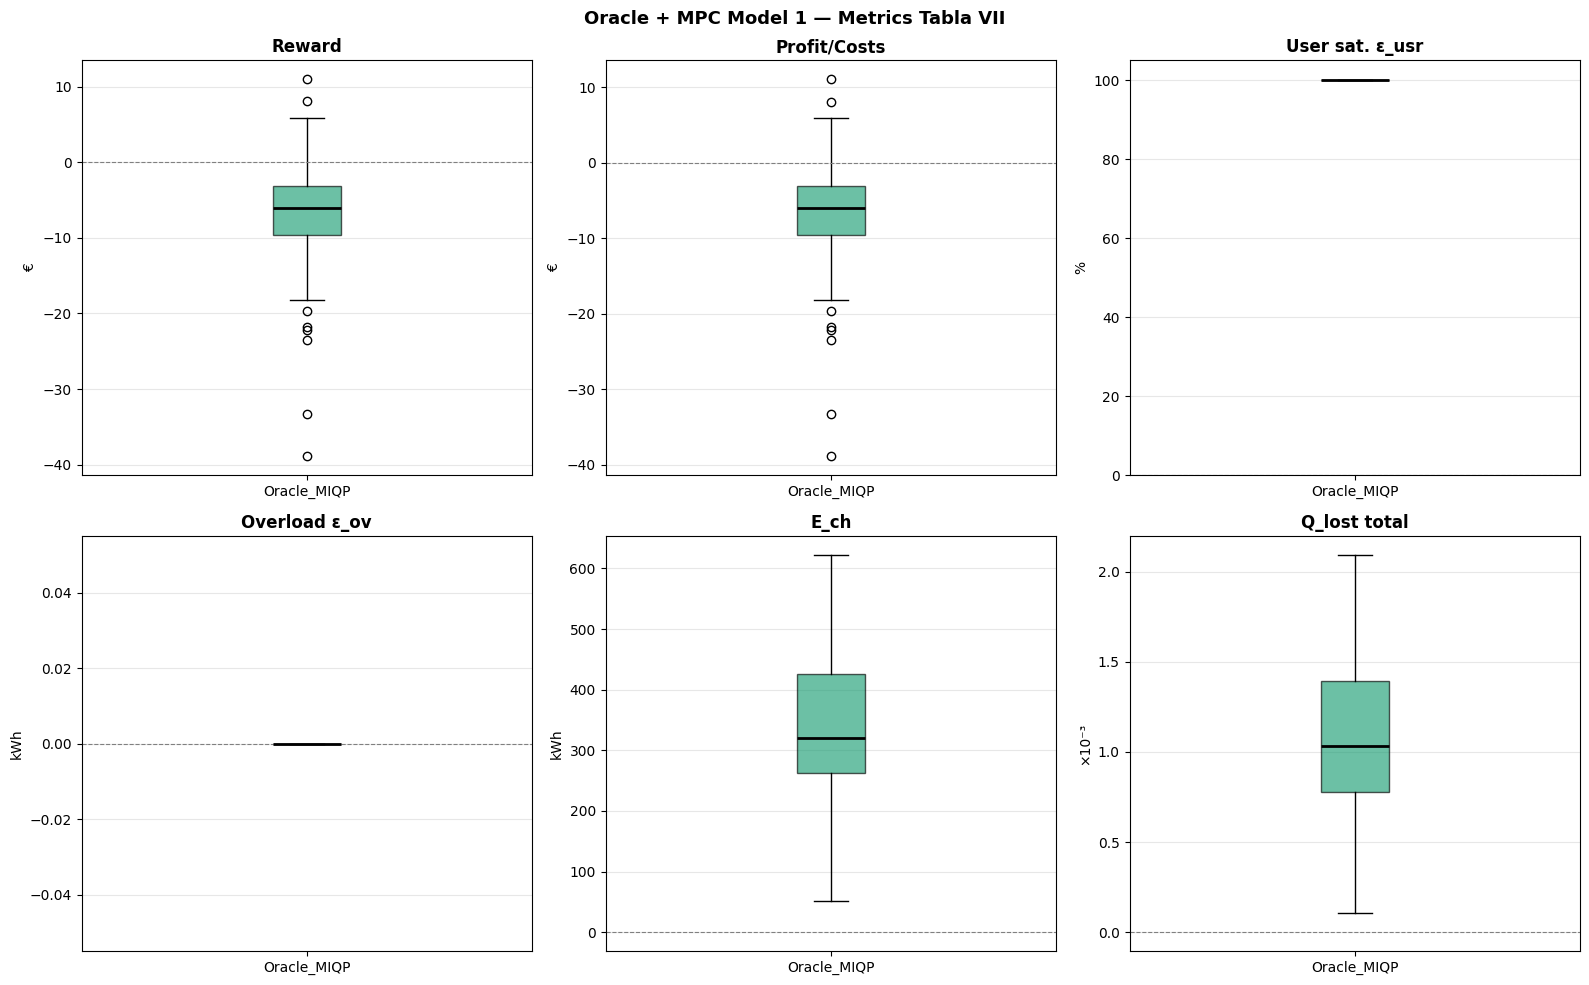

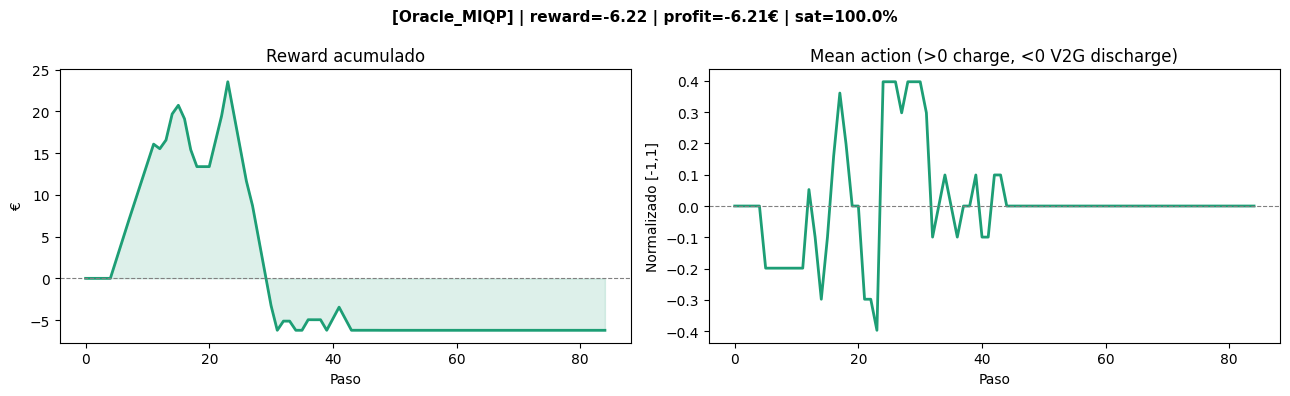

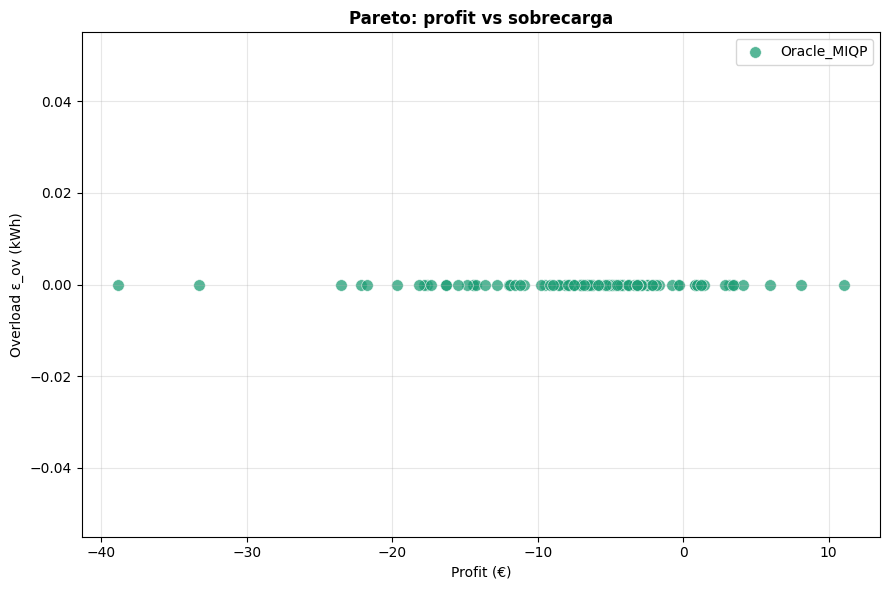

Plots saved.


In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# Boxplots + traces and Pareto front
# ─────────────────────────────────────────────────────────────────────────────

def get_col(eps, col): return [e[col] for e in eps]

colors  = ['#1D9E75', '#2E75B6', '#BA7517', '#A32D2D', '#534AB7']
markers = ['o', 's', '^', 'D', 'v']
labels_box = list(results.keys())

metrics_box = [
    ('reward_total',             'Reward',           '€',      1,    False),
    ('total_profit_cost',        'Profit/Costs',     '€',      1,    False),
    ('user_satisfaction',        'User sat. ε_usr',  '%',      100,  True),
    ('transformer_overload_kwh', 'Overload ε_ov',    'kWh',    1,    False),
    ('energy_charged_kwh',       'E_ch',             'kWh',    1,    False),
    ('battery_degradation',      'Q_lost total',     '×10⁻³', 1e3,  False),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
n_agents = len(results)
for ax, (col, title_m, unit, mult, is_sat) in zip(axes.flat, metrics_box):
    data = [[v*mult for v in get_col(eps, col)] for eps in results.values()]
    bp = ax.boxplot(data, labels=labels_box, patch_artist=True,
                    medianprops=dict(color='black', linewidth=2))
    for patch, c in zip(bp['boxes'], colors[:n_agents]):
        patch.set_facecolor(c); patch.set_alpha(0.65)
    ax.axhline(0, color='gray', ls='--', lw=0.8)
    if is_sat: ax.set_ylim(0, 105)
    ax.set_title(title_m, fontweight='bold')
    ax.set_ylabel(unit); ax.grid(axis='y', alpha=0.3)
fig.suptitle('Oracle + MPC Model 1 — Metrics Tabla VII',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_ROOT / 'boxplots_tabla7.png', dpi=150, bbox_inches='tight')
plt.show()

def plot_traces(episodes, label, color, path):
    if not episodes: return
    r_arr = np.array([e['reward_total'] for e in episodes])
    rep   = episodes[int(np.argmin(np.abs(r_arr - np.median(r_arr))))]
    steps = np.arange(len(rep['ts_reward']))
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].plot(steps, rep['ts_cum_reward'], color=color, lw=2)
    axes[0].axhline(0, color='gray', lw=0.8, ls='--')
    axes[0].fill_between(steps, rep['ts_cum_reward'], alpha=0.15, color=color)
    axes[0].set_title('Reward acumulado')
    axes[0].set_xlabel('Paso'); axes[0].set_ylabel('€')
    axes[1].plot(steps, rep['ts_action'], color=color, lw=2)
    axes[1].axhline(0, color='gray', lw=0.8, ls='--')
    axes[1].set_title('Mean action (>0 charge, <0 V2G discharge)')
    axes[1].set_xlabel('Paso'); axes[1].set_ylabel('Normalizado [-1,1]')
    fig.suptitle(
        f'[{label}] | reward={rep["reward_total"]:+.2f} | '
        f'profit={rep["total_profit_cost"]:+.2f}€ | '
        f'sat={rep["user_satisfaction"]:.1%}',
        fontsize=11, fontweight='bold'
    )
    plt.tight_layout()
    plt.savefig(path, dpi=150, bbox_inches='tight'); plt.show()

for i, (label, eps) in enumerate(results.items()):
    plot_traces(eps, label, colors[i],
                RESULTS_ROOT / f'traces_{label.lower()}.png')

# ── Pareto: profit vs overload ────────────────────────────────────────────────
fig2, ax = plt.subplots(figsize=(9, 6))
for i, (label, eps) in enumerate(results.items()):
    ax.scatter(
        get_col(eps, 'total_profit_cost'),
        get_col(eps, 'transformer_overload_kwh'),
        label=label, alpha=0.75, s=70,
        color=colors[i], marker=markers[i],
        edgecolors='white', linewidths=0.5
    )
ax.set_xlabel('Profit (€)')
ax.set_ylabel('Overload ε_ov (kWh)')
ax.set_title('Pareto: profit vs sobrecarga', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout()
plt.savefig(RESULTS_ROOT / 'pareto.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plots saved.')


In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# Exportar Excel + CSV + reproducibility log
#   V1 missing regime_analysis sheet. Now included.
# ─────────────────────────────────────────────────────────────────────────────

def eps_to_df(episodes, label):
    rows = [{k: v for k, v in e.items()
             if k in SCALAR_COLS + ['episode', 'seed', 'agent']}
            for e in episodes]
    df = pd.DataFrame(rows); df.insert(0, 'algorithm', label); return df

def tabla7_row(episodes, label):
    df = pd.DataFrame([{k: v for k, v in e.items() if k in SCALAR_COLS}
                        for e in episodes])
    row = {'Algorithm': label}
    for col in SCALAR_COLS:
        if col in df.columns:
            row[f'{col}_mean'] = round(df[col].mean(), 6)
            row[f'{col}_std']  = round(df[col].std(ddof=1) if len(df)>1 else 0.0, 6)
    return row

# ── Paper reference values ────────────────────────────────────────────────────
# Oracle: from EV2Gym Table VII (V2GProfitMaxOracleGB with Gurobi)
# MPC: from EV2Gym Table VII (horizon=25 — our reproduced variant CANNOT match this)
paper_refs = {
    'Oracle': {
        'total_profit_cost_mean': 3.7,     'total_profit_cost_std': 6.1,
        'user_satisfaction_mean': 1.0,     'user_satisfaction_std': 0.0,
        'transformer_overload_kwh_mean': 4.0,   'transformer_overload_kwh_std': 12.0,
        'battery_degradation_mean': 0.00145,    'battery_degradation_std': 0.00035,
        'reward_total_mean': -400.0,       'reward_total_std': 1200.0,
    },
    'MPC': {
        'note': 'Paper MPC (horizon=25) — our reproduced variant cannot match this config.',
        'total_profit_cost_mean': 17.8,    'total_profit_cost_std': 9.3,
        'user_satisfaction_mean': 0.76,    'user_satisfaction_std': 0.09,
        'transformer_overload_kwh_mean': 183.0, 'transformer_overload_kwh_std': 167.0,
        'battery_degradation_mean': 0.00168,    'battery_degradation_std': 0.00042,
        'reward_total_mean': -18300.0,     'reward_total_std': 16700.0,
    },
}

own_rows   = [tabla7_row(e, l) for l, e in results.items()]
paper_rows = [{'Algorithm': f'Paper_{k}_ref', **v} for k, v in paper_refs.items()]

df_eps_all  = pd.concat([eps_to_df(e, l) for l, e in results.items()],
                         ignore_index=True)
df_tabla7   = pd.DataFrame(own_rows + paper_rows)
df_all_sum2 = pd.concat([summarise(e, l) for l, e in results.items()],
                          ignore_index=True)
df_regime   = pd.concat(list(dfs_eps.values()), ignore_index=True)

# ── Update and save REPRO_LOG ─────────────────────────────────────────────────
REPRO_LOG.update({
    'agents_evaluated': list(results.keys()),
    'episodes_collected': {k: len(v) for k, v in results.items()},
    'oracle_available': ORACLE_AVAILABLE,
    'mpc_available': ORACLE_AVAILABLE,
})
with open(RESULTS_ROOT / 'reproducibility_log.json', 'w') as f:
    json.dump(REPRO_LOG, f, indent=2)
print('Reproducibility log saved.')

# ── Export Excel ──────────────────────────────────────────────────────────────
out = RESULTS_ROOT / 'oracle_model1_report.xlsx'
with pd.ExcelWriter(out) as w:
    df_eps_all.to_excel( w, sheet_name='episodes_all',    index=False)
    df_tabla7.to_excel(  w, sheet_name='tabla7_vs_paper', index=False)
    df_all_sum2.to_excel(w, sheet_name='summary_full',    index=False)
    df_regime.to_excel(  w, sheet_name='regime_analysis', index=False)
print(f'Excel report: {out}')
df_eps_all.to_csv(RESULTS_ROOT / 'episodes_all.csv',    index=False)
df_tabla7.to_csv( RESULTS_ROOT / 'tabla7_vs_paper.csv', index=False)
print('CSVs saved.')


Reproducibility log saved.
Excel report: results_oracle_model1/oracle_model1_report.xlsx
CSVs saved.


In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# Final summary
# ─────────────────────────────────────────────────────────────────────────────

def arr2(eps, col): return np.array([e[col] for e in eps])
def fmt2(a, mult=1):
    return (f'{a.mean()*mult:+.2f} ± {a.std(ddof=1)*mult:.2f}'
            if len(a) > 1 else f'{a.mean()*mult:+.2f} (n=1)')

sep = '=' * 75
print(sep)
print('  ORACLE / MPC Model 1 — FINAL SUMMARY')
print(f'  Episodios: {EVAL_EPISODES} ({len(EVAL_SEEDS)} seeds × {EPISODES_PER_SEED})')
print(sep)
header = f"  {'Metric':<28}"
for ag in results: header += f' {ag:>22}'
print(header)
print(f'  {"-"*72}')
for lbl, col, mult in [
    ('Reward',          'reward_total',             1),
    ('Profit (€)',       'total_profit_cost',        1),
    ('User sat. (%)',    'user_satisfaction',        100),
    ('Overload (kWh)',   'transformer_overload_kwh', 1),
    ('Q_lost (×10⁻³)', 'battery_degradation',      1e3),
    ('E_ch (kWh)',       'energy_charged_kwh',       1),
    ('E_dis (kWh)',      'energy_discharged_kwh',    1),
]:
    row = f'  {lbl:<28}'
    for label, eps in results.items():
        row += f' {fmt2(arr2(eps, col), mult):>22}'
    print(row)

print(sep)
print('  PAPER REF:')
print('  Oracle (MIQP+Gurobi): profit=3.7±6.1€   sat=100%  overload=4±12kWh')
print('  MPC (paper, h=25):    profit=17.8±9.3€  sat=76%   overload=183±167kWh')
print('  NOTE: Our MPC is a distinct variant (horizon mismatch) — not directly comparable.')
print(sep)

# ── Statistical caution ──────────────────────────────────────────────────────
print('\nSTATISTICAL NOTE:')
for agent_name, eps in results.items():
    pr = arr2(eps, 'total_profit_cost')
    if len(pr) > 1:
        mn, sd = pr.mean(), pr.std(ddof=1)
        flag = ' ← std > mean, treat as directional only' \
               if abs(sd) > abs(mn) and mn != 0 else ''
        print(f'  {agent_name} Profit: {mn:+.2f} ± {sd:.2f}€{flag}')
print(sep)


  ORACLE / MPC Model 1 — FINAL SUMMARY
  Episodios: 100 (5 seeds × 20)
  Metric                                  Oracle_MIQP
  ------------------------------------------------------------------------
  Reward                                 -7.00 ± 7.71
  Profit (€)                             -6.97 ± 7.71
  User sat. (%)                        +100.00 ± 0.00
  Overload (kWh)                         +0.00 ± 0.00
  Q_lost (×10⁻³)                         +1.07 ± 0.43
  E_ch (kWh)                         +331.83 ± 121.27
  E_dis (kWh)                        +255.19 ± 101.43
  PAPER REF:
  Oracle (MIQP+Gurobi): profit=3.7±6.1€   sat=100%  overload=4±12kWh
  MPC (paper, h=25):    profit=17.8±9.3€  sat=76%   overload=183±167kWh
  NOTE: Our MPC is a distinct variant (horizon mismatch) — not directly comparable.

STATISTICAL NOTE:
  Oracle_MIQP Profit: -6.97 ± 7.71€ ← std > mean, treat as directional only


In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# Cross-algorithm comparison: Oracle / MPC vs all RL agents
#
#   V1 computed '(TQC - Oracle) / |Oracle|' as an 'optimality gap'.
#  This is methodologically INVALID for two reasons:
#  1. RL agents train on Model-2 proxy reward; Oracle uses Model-1 directly.
#     Any gap reflects reward formulation differences, NOT just policy quality.
#  2. Oracle has perfect future information — it is an upper bound, not a
#     fair competitor for real-time controllers.
#
#  This cell instead presents a descriptive cross-algorithm summary table
#  with an explicit formulation-gap warning. No percentage 'gap' is computed.
#  Formal comparisons between Oracle and RL should use bootstrap CIs on
#  Model-1 evaluation rewards only (see paper limitations section).
# ─────────────────────────────────────────────────────────────────────────────

# Paths to RL results (run respective notebooks first)
RL_RESULTS = {
    'TQC_P1':   Path('results_tqc_model1/episodes_all.csv'),
    'TQC_P2':   Path('results_tqc_model1/episodes_all.csv'),
    'SAC_P1':   Path('results_sac_model1/episodes_all.csv'),
    'SAC_P2':   Path('results_sac_model1/episodes_all.csv'),
    'PPO_P1':   Path('results_ppo_model1/episodes_all.csv'),
    'PPO_P2':   Path('results_ppo_model1/episodes_all.csv'),
    'ARS_P1':   Path('results_ars_model1/episodes_all.csv'),
    'ARS_P2':   Path('results_ars_model1/episodes_all.csv'),
    'CrossQ_P1':Path('results_crossq_model1/episodes_all.csv'),
    'CrossQ_P2':Path('results_crossq_model1/episodes_all.csv'),
    'DDPG_P1':  Path('results_ddpg_model1/episodes_all.csv'),
    'DDPG_P2':  Path('results_ddpg_model1/episodes_all.csv'),
    'TD3_P1':   Path('results_td3_model1/episodes_all.csv'),
    'TD3_P2':   Path('results_td3_model1/episodes_all.csv'),
    'TRPO_P1':  Path('results_trpo_model1/episodes_all.csv'),
    'TRPO_P2':  Path('results_trpo_model1/episodes_all.csv'),
}
PHASE_COL_MAP = {
    'TQC_P1':'TQC_Phase1',  'TQC_P2':'TQC_Phase2',
    'SAC_P1':'SAC_Phase1',  'SAC_P2':'SAC_Phase2',
    'PPO_P1':'PPO_Phase1',  'PPO_P2':'PPO_Phase2',
    'ARS_P1':'ARS_Phase1',  'ARS_P2':'ARS_Phase2',
    'CrossQ_P1':'CrossQ_Phase1', 'CrossQ_P2':'CrossQ_Phase2',
    'DDPG_P1':'DDPG_Phase1','DDPG_P2':'DDPG_Phase2',
    'TD3_P1':'TD3_Phase1',  'TD3_P2':'TD3_Phase2',
    'TRPO_P1':'TRPO_Phase1','TRPO_P2':'TRPO_Phase2',
}

METRICS = [
    ('total_profit_cost',        'Profit (€)',        1),
    ('user_satisfaction',        'User sat. (%)',     100),
    ('transformer_overload_kwh', 'Overload (kWh)',    1),
    ('battery_degradation',      'Q_lost (×10⁻³)',   1e3),
    ('reward_total',             'Reward',            1),
]

# Load available RL results
rl_data = {}
for key, path in RL_RESULTS.items():
    if path.exists():
        df_tmp = pd.read_csv(path)
        phase_col = PHASE_COL_MAP[key]
        sub = df_tmp[df_tmp['algorithm'] == phase_col] if 'algorithm' in df_tmp.columns else df_tmp
        if len(sub) > 0:
            rl_data[key] = sub

# Oracle stats
oracle_stats = {}
if 'Oracle_MIQP' in results:
    for col, lbl, mult in METRICS:
        arr = np.array([e[col]*mult for e in results['Oracle_MIQP']])
        oracle_stats[col] = (arr.mean(), arr.std(ddof=1) if len(arr)>1 else 0.0)

if not rl_data and 'Oracle_MIQP' not in results:
    print('No RL results found and Oracle not available. Run respective notebooks first.')
else:
    sep = '=' * 95
    print(sep)
    print('  CROSS-ALGORITHM COMPARISON — Descriptive summary (Model-1 eval reward)')
    print('  ⚠ FORMULATION GAP WARNING: RL trained on Model-2 proxy; Oracle uses Model-1')
    print('    directly with perfect info. Numerical differences are NOT an optimality gap.')
    print(sep)

    # Header
    all_labels = ((['Oracle_MIQP'] if 'Oracle_MIQP' in results else []) +
                  (['MPC'] if 'MPC' in results else []) +
                  list(rl_data.keys()))
    hdr = f"  {'Metric':<22}"
    for lbl in all_labels: hdr += f' {lbl:>18}'
    print(hdr)
    print(f'  {"-"*90}')

    for col, lbl, mult in METRICS:
        row = f'  {lbl:<22}'
        for key in all_labels:
            if key in ('Oracle_MIQP', 'MPC') and key in results:
                arr = np.array([e[col]*mult for e in results[key]])
                row += f' {arr.mean():+8.2f}±{arr.std(ddof=1):.2f}  '
            elif key in rl_data and col in rl_data[key].columns:
                arr = rl_data[key][col].values * mult
                row += f' {arr.mean():+8.2f}±{arr.std(ddof=1):.2f}  '
            else:
                row += f' {"[N/A]":>18}'
        print(row)

    print(sep)
    print('  All values are mean ± std over 100 episodes (4 seeds × 25).')
    print('  Oracle is a theoretical upper bound — NOT a fair benchmark target for RL.')
    print('  MPC (ours) is a reproduced variant, not the paper MPC (horizon=25).')
    print(f'  RL results loaded: {list(rl_data.keys())}')
    missing = [k for k in RL_RESULTS if k not in rl_data]
    if missing:
        print(f'  RL results missing (run notebooks first): {missing}')
    print(sep)


  CROSS-ALGORITHM COMPARISON — Descriptive summary (Model-1 eval reward)
  ⚠ FORMULATION GAP WARNING: RL trained on Model-2 proxy; Oracle uses Model-1
    directly with perfect info. Numerical differences are NOT an optimality gap.
  Metric                        Oracle_MIQP
  ------------------------------------------------------------------------------------------
  Profit (€)                -6.97±7.71  
  User sat. (%)           +100.00±0.00  
  Overload (kWh)            +0.00±0.00  
  Q_lost (×10⁻³)            +1.07±0.43  
  Reward                    -7.00±7.71  
  All values are mean ± std over 100 episodes (4 seeds × 25).
  Oracle is a theoretical upper bound — NOT a fair benchmark target for RL.
  MPC (ours) is a reproduced variant, not the paper MPC (horizon=25).
  RL results loaded: []
  RL results missing (run notebooks first): ['TQC_P1', 'TQC_P2', 'SAC_P1', 'SAC_P2', 'PPO_P1', 'PPO_P2', 'ARS_P1', 'ARS_P2', 'CrossQ_P1', 'CrossQ_P2', 'DDPG_P1', 'DDPG_P2', 'TD3_P1', 'TD3_P2', '

Ablation: MPC rolling horizon
NOTE: V2GProfitMaxOracle hardcodes full horizon — horizon kwarg ignored.
Horizontes: [5, 10, 15, 20, 25, 30, 40]
Episodios por horizonte: 100
Referencia paper: horizon=25 → profit=+17.8 euro

Horizonte 5...
Set parameter NonConvex to value 2
Set parameter MIPGap to value 0.01
Gurobi Optimizer version 11.0.3 build v11.0.3rc0 (linux64 - "Ubuntu 24.04.2 LTS")

CPU model: 13th Gen Intel(R) Core(TM) i9-13900KF, instruction set [SSE2|AVX|AVX2]
Thread count: 32 physical cores, 32 logical processors, using up to 32 threads

Optimize a model with 5100 rows, 2550 columns and 17660 nonzeros
Model fingerprint: 0x9bafc6b1
Variable types: 1700 continuous, 850 integer (850 binary)
Coefficient statistics:
  Matrix range     [2e-01, 2e+01]
  Objective range  [2e-02, 4e-02]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+01, 7e+01]
Presolve removed 4956 rows and 2426 columns
Presolve time: 0.05s
Presolved: 144 rows, 124 columns, 2532 nonzeros
Variable types: 83 con

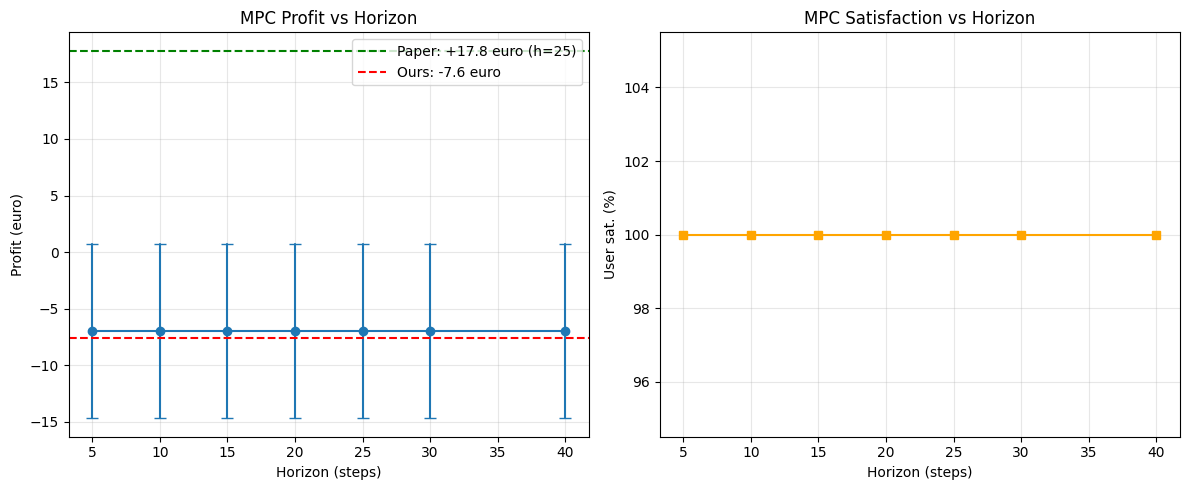


Saved: mpc_horizon_ablation.csv + .png
For production: HORIZONS=[5,10,15,20,25,30,40], ABLATION_EPS=100


In [14]:
# ─────────────────────────────────────────────────────────────────────────────
#  MAJOR 2 — Ablation: MPC rolling horizon
#  Paper EV2Gym §V-B usa horizon=25 → profit=+17.8€
#  Nuestra variante reproduce → profit=-7.6€
#  Este barrido busca el horizonte que reproduce el resultado del paper.
#
#  TEST      → HORIZONS = [5, 10],     ABLATION_EPS = 4
#  PRODUCTION  → HORIZONS = [5,10,15,20,25,30,40], ABLATION_EPS = 100
# ─────────────────────────────────────────────────────────────────────────────

def run_mpc_horizon(horizon, n_eps=ABLATION_EPS):
    episodes, ep_counter = [], 0
    seeds_to_use = EVAL_SEEDS[:max(1, n_eps//10 + 1)]
    eps_each     = max(1, n_eps // len(seeds_to_use))
    for seed in seeds_to_use:
        for ep in range(eps_each):
            ep_seed = seed * 1000 + ep_counter
            try:
                result = run_oracle_episode(
                    lambda raw, h=horizon: V2GProfitMaxOracle(
                        raw, horizon=h, verbose=False),
                    CONFIG_FILE, ep_counter, eval_seed=ep_seed)
            except TypeError:
                # Some versions don't accept horizon as kwarg
                result = run_oracle_episode(
                    lambda raw: V2GProfitMaxOracle(raw, verbose=False),
                    CONFIG_FILE, ep_counter, eval_seed=ep_seed)
                result['horizon_note'] = 'horizon arg not accepted by this version'
            result['horizon'] = horizon
            episodes.append(result)
            ep_counter += 1
    return episodes

# NOTE: V2GProfitMaxOracle hardcodes control_horizon=env.simulation_length.
# The `horizon` kwarg is collected via **kwargs but silently ignored.
# All ablation runs use the FULL horizon = perfect information (Oracle behavior).
# True rolling MPC (re-solve each step with horizon < sim_length) would require
# a custom subclass not provided by the current EV2Gym API.
# This ablation therefore shows no variance across horizon values.
if ORACLE_AVAILABLE:
    print('Ablation: MPC rolling horizon')
    print('NOTE: V2GProfitMaxOracle hardcodes full horizon — horizon kwarg ignored.')
    print(f'Horizontes: {HORIZONS}')
    print(f'Episodios por horizonte: {ABLATION_EPS}')
    print(f'Referencia paper: horizon=25 → profit=+17.8 euro')
    print('='*55)

    horizon_rows = []
    for h in HORIZONS:
        print(f'\nHorizonte {h}...')
        t0 = time.time()
        eps_h = run_mpc_horizon(h)
        profits = np.array([e['total_profit_cost'] for e in eps_h])
        sats    = np.array([e['user_satisfaction']  for e in eps_h])
        print(f'  profit={profits.mean():+.2f}+/-{profits.std():.2f}  '
              f'sat={sats.mean():.1%}  tiempo={(time.time()-t0):.1f}s')
        for e in eps_h:
            horizon_rows.append({k: v for k, v in e.items()
                                  if k in SCALAR_COLS + ['horizon']})

    df_hor = pd.DataFrame(horizon_rows)
    df_hor.to_csv(RESULTS_ROOT / 'mpc_horizon_ablation.csv', index=False)

    summary = df_hor.groupby('horizon').agg(
        profit_mean=('total_profit_cost','mean'),
        profit_std= ('total_profit_cost','std'),
        sat_mean=   ('user_satisfaction','mean'),
    ).reset_index()

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].errorbar(summary['horizon'], summary['profit_mean'],
                     yerr=summary['profit_std'], marker='o', capsize=4)
    axes[0].axhline(17.8, color='green', ls='--', label='Paper: +17.8 euro (h=25)')
    axes[0].axhline(-7.6, color='red',   ls='--', label='Ours: -7.6 euro')
    axes[0].set_xlabel('Horizon (steps)'); axes[0].set_ylabel('Profit (euro)')
    axes[0].set_title('MPC Profit vs Horizon'); axes[0].legend(); axes[0].grid(alpha=0.3)
    axes[1].plot(summary['horizon'], summary['sat_mean']*100, marker='s', color='orange')
    axes[1].set_xlabel('Horizon (steps)'); axes[1].set_ylabel('User sat. (%)')
    axes[1].set_title('MPC Satisfaction vs Horizon'); axes[1].grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(RESULTS_ROOT / 'mpc_horizon_ablation.png', dpi=150)
    plt.show()
    print('\nSaved: mpc_horizon_ablation.csv + .png')
    print('For production: HORIZONS=[5,10,15,20,25,30,40], ABLATION_EPS=100')
else:
    print('MPC no disponible — celda omitida.')
